<a href="https://colab.research.google.com/github/Muhammad-Khizer-Hayat/Ai_ChatBot/blob/main/cats_vs_dogsCNNmodel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install opendatasets

In [6]:
import opendatasets as od
od.download('https://www.kaggle.com/competitions/dogs-vs-cats-redux-kernels-edition/data')

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: muhammadkhizarhayat
Your Kaggle Key: ··········


100%|██████████| 814M/814M [00:39<00:00, 21.8MB/s]



Extracting archive ./dogs-vs-cats-redux-kernels-edition/dogs-vs-cats-redux-kernels-edition.zip to ./dogs-vs-cats-redux-kernels-edition


In [7]:
import zipfile
import os

# Folder created by opendatasets
dataset_path = "dogs-vs-cats-redux-kernels-edition"

# Unzip train.zip
with zipfile.ZipFile(os.path.join(dataset_path, "train.zip"), "r") as zip_ref:
    zip_ref.extractall(dataset_path)

# Unzip test.zip
with zipfile.ZipFile(os.path.join(dataset_path, "test.zip"), "r") as zip_ref:
    zip_ref.extractall(dataset_path)

print("Done!")

Done!


In [10]:
import os
import shutil
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [12]:
#Path Organize
base_path = "/content/dogs-vs-cats-redux-kernels-edition"
train_dir = os.path.join(base_path, "train")

cats_dir = os.path.join(base_path, "cats")
dogs_dir = os.path.join(base_path, "dogs")
os.makedirs(cats_dir, exist_ok=True)
os.makedirs(dogs_dir, exist_ok=True)
if not os.listdir(cats_dir) and not os.listdir(dogs_dir):
    for file in os.listdir(train_dir):
        src = os.path.join(train_dir, file)
        if file.startswith("cat"):
            shutil.copy(src, cats_dir)
        elif file.startswith("dog"):
            shutil.copy(src, dogs_dir)
    print("Done organizing files!")
else:
    print("Files already organized, skipping.")

Done organizing files!


In [13]:
# Data Generator
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)
# print(train_datagen)

In [14]:
# train the datsets
train_data = train_datagen.flow_from_directory(
    base_path,
    classes=["cats", "dogs"],
    target_size=(128, 128),
    batch_size=32,
    class_mode="binary",
    subset="training",
    seed=42
)

Found 20000 images belonging to 2 classes.


In [15]:
# validate the dats
val_data = val_datagen.flow_from_directory(
    base_path,
    classes=["cats", "dogs"],
    target_size=(128, 128),
    batch_size=32,
    class_mode="binary",
    subset="validation",
    seed=42
)


Found 5000 images belonging to 2 classes.


In [16]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,422,401 (5.43 MB)

 Trainable params: 1,421,697 (5.42 MB)

 Non-trainable params: 704 (2.75 KB)

In [17]:
# Test and validate the model
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_loss',
    save_best_only=True
)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=25,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 134s 197ms/step - accuracy: 0.6255 - loss: 0.7263 - val_accuracy: 0.6722 - val_loss: 0.6158
Epoch 2/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 120s 193ms/step - accuracy: 0.6858 - loss: 0.5882 - val_accuracy: 0.7284 - val_loss: 0.5310
Epoch 3/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 119s 191ms/step - accuracy: 0.7359 - loss: 0.5297 - val_accuracy: 0.7828 - val_loss: 0.4532
Epoch 4/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 120s 192ms/step - accuracy: 0.7801 - loss: 0.4680 - val_accuracy: 0.8424 - val_loss: 0.3646
Epoch 5/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 119s 191ms/step - accuracy: 0.8143 - loss: 0.4098 - val_accuracy: 0.8384 - val_loss: 0.3639
Epoch 6/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 121s 193ms/step - accuracy: 0.8342 - loss: 0.3736 - val_accuracy: 0.8178 - val_loss: 0.4170
Epoch 7/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 119s 190ms/step - accuracy: 0.8508 - loss: 0.3420 - val_accuracy: 0.8876 - val_loss: 0.2661
Epoch 8/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 123s 197ms/step - accuracy: 0.8605 -

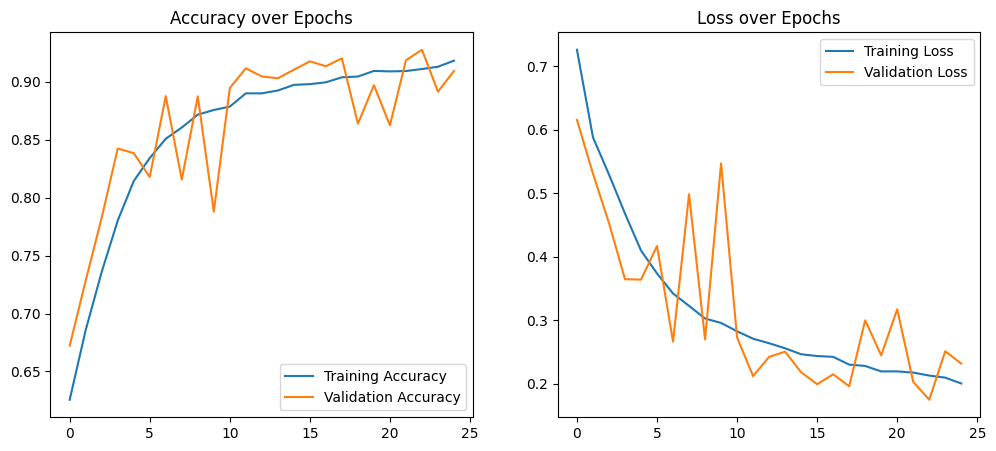

In [18]:
# Generate t the plot after check

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Accuracy over Epochs')

plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Loss over Epochs')

plt.show()

In [19]:
import time

val_loss_final, val_accuracy_final = model.evaluate(val_data)
print(f"Validation Loss: {val_loss_final:.4f}")
print(f"Validation Accuracy: {val_accuracy_final:.4f}")


157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - accuracy: 0.9276 - loss: 0.1745
Validation Loss: 0.1745
Validation Accuracy: 0.9276


In [71]:
import cv2
# Load image
test_image = cv2.imread('/content/cats.jpg')


In [72]:
test_image.shape

(148, 191, 3)

In [73]:
test_image=cv2.resize(test_image,(128,128))


In [74]:
test_input=test_image.reshape(1,128,128,3)


In [75]:

model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


array([[0.]], dtype=float32)